Because naive bayes needs independent categories to to function correctly, we can't use one hot encoding and have to format the data differently. The data is the same but we use an ordinal encoder for the categorical features instead. Otherwise the naive bayes approach would likely perform very badly.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split    
from sklearn.svm import SVC

pd.set_option('display.max_columns', None)

In [35]:
df = pd.read_csv('../Data/raw_data.csv', sep=';')

columns_to_drop = ['stem-root','veil-type', 'veil-color',  'stem-surface', 'spore-print-color']
df = df.drop(columns=columns_to_drop)
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'has-ring', 'ring-type',
       'habitat', 'season'],
      dtype='object')

In [36]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline


class KNNCategoricalImputer(BaseEstimator, TransformerMixin):
    """
    Supervised KNN imputer for one or more categorical columns.

    - Assumes input X is a pandas DataFrame with original columns.
    - For each target column:
        * uses all other columns that have no missing values as predictors
        * does its own StandardScaler + OneHotEncoder internally
    """

    def __init__(self, target_cols, num_cols=None, n_neighbors=5, weights="distance"):
        # allow a single string or a list
        if isinstance(target_cols, str):
            target_cols = [target_cols]

        self.target_cols = target_cols
        self.num_cols = num_cols   # list of numeric columns to scale 
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y=None):
        df = X.copy()

        self.knn_models_ = {}
        self.feature_cols_ = {}

        for col in self.target_cols:
            # rows where the target is known
            mask = df[col].notna()

            # trainable columns: all except the target, and with no missing values on these rows
            _X_train_tmp = df.loc[mask].drop(columns=[col])
            train_columns = _X_train_tmp.columns[
                _X_train_tmp.isnull().sum() == 0
            ].tolist()

            X_train = df.loc[mask, train_columns]
            y_train = df.loc[mask, col]

            # numeric + categorical columns for THIS target
            if self.num_cols is None:
                # if not provided, infer numeric from dtypes
                num_cols = X_train.select_dtypes(include="number").columns.tolist()
            else:
                # keep only those num_cols that are actually in train_columns
                num_cols = [c for c in self.num_cols if c in train_columns]

            cat_cols = [c for c in train_columns if c not in num_cols + [col]]

            # preprocessor for KNN
            pre = ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), num_cols),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
                ]
            )

            # KNN classifier pipeline
            clf = Pipeline(
                steps=[
                    ("pre", pre),
                    (
                        "knn",
                        KNeighborsClassifier(
                            n_neighbors=self.n_neighbors, weights=self.weights
                        ),
                    ),
                ]
            )

            # fit KNN for this target column
            clf.fit(X_train, y_train)

            # store model and the columns it expects
            self.knn_models_[col] = clf
            self.feature_cols_[col] = train_columns

        return self

    def transform(self, X):
        df = X.copy()

        for col in self.target_cols:
            mask_missing = df[col].isna()

            if mask_missing.any():
                feats = self.feature_cols_[col]
                X_missing = df.loc[mask_missing, feats]
                df.loc[mask_missing, col] = self.knn_models_[col].predict(X_missing)

        return df

In [37]:
from sklearn import set_config
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
set_config(transform_output="pandas") 


x = df.drop(columns='class')
y = df['class']

# label encode y 

le = LabelEncoder()
y = le.fit_transform(y)

numeric_features = x.select_dtypes(include='float64').columns.to_list()
categorical_features = x.select_dtypes(include='object').columns.to_list()

# Columns to impute
features_to_impute = ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

numeric_transformer = StandardScaler()

# Use OrdinalEncoder instead of OneHotEncoder for mixed Naive Bayes
categorical_transformer = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)


knn_imputer = KNNCategoricalImputer(
    target_cols=features_to_impute,
    num_cols=numeric_features
)


column_trans = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)


preprocess = Pipeline(steps=[
    ('knn_imputer', knn_imputer),      # impute missing values using KNN 
    ('column_transformer', column_trans)  
])


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


preprocess.fit(x_train)

x_train = preprocess.transform(x_train)
x_test = preprocess.transform(x_test)

x_train


,cap-diameter,stem-height,stem-width,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-color,has-ring,ring-type,habitat,season
36219,-0.195867,-0.104756,-0.639647,6.0,3.0,5.0,0.0,6.0,0.0,5.0,6.0,1.0,6.0,0.0,2.0
54188,0.039043,-0.801696,-0.439222,5.0,0.0,6.0,0.0,1.0,0.0,11.0,12.0,0.0,1.0,2.0,2.0
1609,0.313735,1.253535,0.218893,6.0,3.0,8.0,0.0,2.0,0.0,10.0,11.0,1.0,2.0,0.0,2.0
20481,-0.616430,-0.736450,-0.574833,6.0,0.0,1.0,0.0,0.0,0.0,6.0,7.0,0.0,1.0,4.0,2.0
20546,-0.654319,-0.819490,-0.613722,6.0,3.0,7.0,0.0,0.0,0.0,1.0,7.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28217,0.012521,-0.629685,0.036415,5.0,8.0,2.0,1.0,1.0,1.0,10.0,9.0,0.0,1.0,0.0,2.0
51211,-0.455404,0.013872,-0.044353,6.0,7.0,6.0,0.0,4.0,0.0,5.0,1.0,0.0,1.0,0.0,0.0
47433,-0.872179,0.289682,-0.984659,0.0,7.0,3.0,0.0,0.0,0.0,4.0,6.0,0.0,1.0,1.0,0.0
40186,-0.819135,-1.021158,-0.846056,2.0,7.0,9.0,0.0,0.0,0.0,10.0,11.0,0.0,1.0,0.0,0.0


In [38]:
y_train

array([0, 1, 1, ..., 1, 1, 0], shape=(48855,))

## Naive Bayes Implementation

Since there are different ways to approach this using naive bayes, I want to compare using the simpler gaussian naive bayes for everything (even categoric features) versus a mixed approach that combines gaussian for numeric and categorical naive bayes for categorical features.

In [39]:
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import seaborn as sns
import numpy as np



### Identify Feature Types

We need to specify which features are numeric vs categorical for the mixed Naive Bayes model.


In [40]:
# Identify which columns are numeric vs categorical
numeric_cols = ['cap-diameter', 'stem-height', 'stem-width']
numeric_indices = [x_train.columns.get_loc(col) for col in numeric_cols if col in x_train.columns]
categorical_indices = [i for i in range(x_train.shape[1]) if i not in numeric_indices]

print(f"Numeric features (indices): {numeric_indices}")
print(f"Total features: {x_train.shape[1]}")
print(f"Numeric features: {len(numeric_indices)}")
print(f"Categorical features: {len(categorical_indices)}")

# Split the data into numeric and categorical parts
x_train_numeric = x_train.iloc[:, numeric_indices].values
x_train_cat = x_train.iloc[:, categorical_indices].values
x_test_numeric = x_test.iloc[:, numeric_indices].values
x_test_cat = x_test.iloc[:, categorical_indices].values


Numeric features (indices): [0, 1, 2]
Total features: 15
Numeric features: 3
Categorical features: 12


### Approach 1: Mixed Naive Bayes (GaussianNB + CategoricalNB)


In [41]:
# Create and train separate models for numeric and categorical features
nb_numeric = GaussianNB()  # For numeric features (cap-diameter, stem-height, stem-width)
nb_cat = CategoricalNB()   # For categorical features (ordinal encoded)

# Train both models
nb_numeric.fit(x_train_numeric, y_train)
nb_cat.fit(x_train_cat, y_train)

print("Models trained successfully!")
print(f"GaussianNB trained on {x_train_numeric.shape[1]} numeric features")
print(f"CategoricalNB trained on {x_train_cat.shape[1]} categorical features")


Models trained successfully!
GaussianNB trained on 3 numeric features
CategoricalNB trained on 12 categorical features


### Evaluate Approach 1 (Mixed)


In [42]:
# Get log probabilities from each model
log_proba_numeric_train = nb_numeric.predict_log_proba(x_train_numeric)
log_proba_cat_train = nb_cat.predict_log_proba(x_train_cat)
log_proba_numeric_test = nb_numeric.predict_log_proba(x_test_numeric)
log_proba_cat_test = nb_cat.predict_log_proba(x_test_cat)

# Combine log probabilities (add them, since log(a*b) = log(a) + log(b))
combined_log_proba_train = log_proba_numeric_train + log_proba_cat_train
combined_log_proba_test = log_proba_numeric_test + log_proba_cat_test

# Convert back to probabilities and predict
combined_proba_train = np.exp(combined_log_proba_train)
combined_proba_test = np.exp(combined_log_proba_test)

nb_mixed_y_pred = np.argmax(combined_proba_test, axis=1)
nb_mixed_y_pred_train = np.argmax(combined_proba_train, axis=1)

# Calculate accuracies
nb_mixed_test_accuracy = accuracy_score(y_test, nb_mixed_y_pred)
nb_mixed_train_accuracy = accuracy_score(y_train, nb_mixed_y_pred_train)

print(f"Training Accuracy: {nb_mixed_train_accuracy:.4f}")
print(f"Test Accuracy: {nb_mixed_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_mixed_y_pred))


Training Accuracy: 0.6574
Test Accuracy: 0.6574

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.46      0.54      5436
           1       0.65      0.82      0.73      6778

    accuracy                           0.66     12214
   macro avg       0.66      0.64      0.63     12214
weighted avg       0.66      0.66      0.64     12214



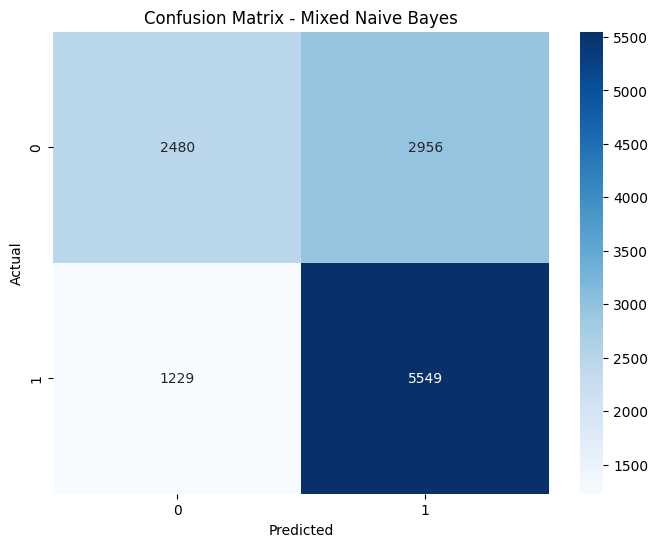

In [43]:
cm_mixed = confusion_matrix(y_test, nb_mixed_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mixed, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Mixed Naive Bayes')
plt.show()


Here is the gaussian only approach now.

In [44]:
nb_simple = GaussianNB()
nb_simple.fit(x_train.values, y_train)

nb_simple_y_pred = nb_simple.predict(x_test.values)
nb_simple_y_pred_train = nb_simple.predict(x_train.values)

nb_simple_test_accuracy = accuracy_score(y_test, nb_simple_y_pred)
nb_simple_train_accuracy = accuracy_score(y_train, nb_simple_y_pred_train)

print(f"Training Accuracy: {nb_simple_train_accuracy:.4f}")
print(f"Test Accuracy: {nb_simple_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_simple_y_pred))

Training Accuracy: 0.5975
Test Accuracy: 0.5973

Classification Report:


              precision    recall  f1-score   support

           0       0.57      0.38      0.45      5436
           1       0.61      0.77      0.68      6778

    accuracy                           0.60     12214
   macro avg       0.59      0.58      0.57     12214
weighted avg       0.59      0.60      0.58     12214



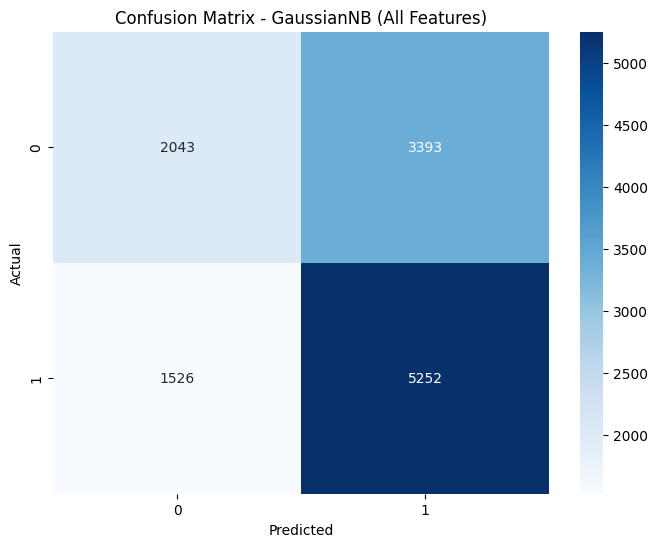

In [45]:
cm_simple = confusion_matrix(y_test, nb_simple_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - GaussianNB (All Features)')
plt.show()


### Comparison of Both Approaches


In [46]:
from sklearn.metrics import f1_score

# Get probabilities for both approaches
nb_mixed_proba = combined_proba_test
nb_mixed_proba_positive = nb_mixed_proba[:, 1]

nb_simple_proba = nb_simple.predict_proba(x_test.values)
nb_simple_proba_positive = nb_simple_proba[:, 1]

# Calculate metrics for comparison
print("=" * 70)
print("COMPARISON OF BOTH APPROACHES")
print("=" * 70)

comparison = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Test Accuracy', 'Train-Test Gap', 
               'F1 Score (Test)', 'F1 Score (Train)'],
    'Mixed (GaussianNB + CategoricalNB)': [
        f"{nb_mixed_train_accuracy:.4f}",
        f"{nb_mixed_test_accuracy:.4f}",
        f"{nb_mixed_train_accuracy - nb_mixed_test_accuracy:.4f}",
        f"{f1_score(y_test, nb_mixed_y_pred):.4f}",
        f"{f1_score(y_train, nb_mixed_y_pred_train):.4f}"
    ],
    'Simple (GaussianNB All)': [
        f"{nb_simple_train_accuracy:.4f}",
        f"{nb_simple_test_accuracy:.4f}",
        f"{nb_simple_train_accuracy - nb_simple_test_accuracy:.4f}",
        f"{f1_score(y_test, nb_simple_y_pred):.4f}",
        f"{f1_score(y_train, nb_simple_y_pred_train):.4f}"
    ]
})

print(comparison.to_string(index=False))
print("\n" + "=" * 70)


COMPARISON OF BOTH APPROACHES
           Metric Mixed (GaussianNB + CategoricalNB) Simple (GaussianNB All)
Training Accuracy                             0.6574                  0.5975
    Test Accuracy                             0.6574                  0.5973
   Train-Test Gap                             0.0001                  0.0002
  F1 Score (Test)                             0.7262                  0.6811
 F1 Score (Train)                             0.7251                  0.6799



### ROC Curves Comparison


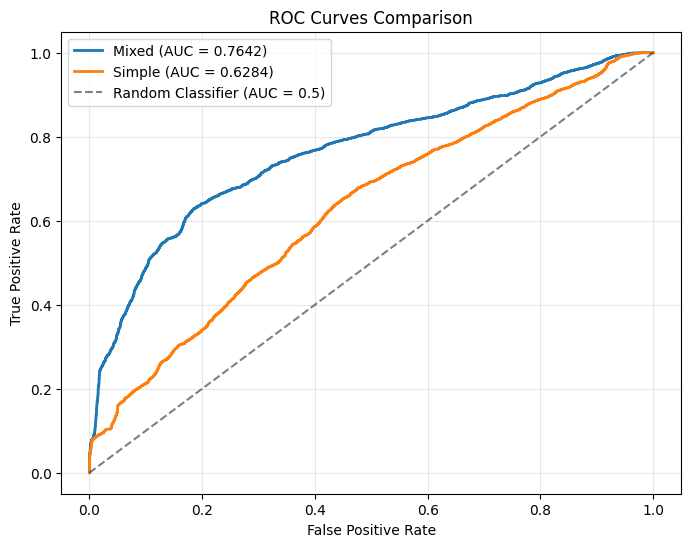

In [47]:
fpr_mixed, tpr_mixed, _ = roc_curve(y_test, nb_mixed_proba_positive)
auc_mixed = roc_auc_score(y_test, nb_mixed_proba_positive)

fpr_simple, tpr_simple, _ = roc_curve(y_test, nb_simple_proba_positive)
auc_simple = roc_auc_score(y_test, nb_simple_proba_positive)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mixed, tpr_mixed, label=f'Mixed (AUC = {auc_mixed:.4f})', linewidth=2)
plt.plot(fpr_simple, tpr_simple, label=f'Simple (AUC = {auc_simple:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Precision-Recall Curves Comparison


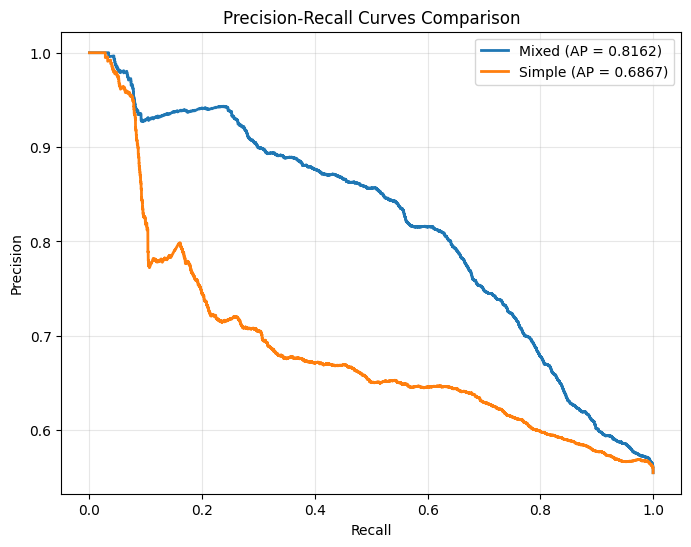

In [48]:
precision_mixed, recall_mixed, _ = precision_recall_curve(y_test, nb_mixed_proba_positive)
ap_mixed = average_precision_score(y_test, nb_mixed_proba_positive)

precision_simple, recall_simple, _ = precision_recall_curve(y_test, nb_simple_proba_positive)
ap_simple = average_precision_score(y_test, nb_simple_proba_positive)

plt.figure(figsize=(8, 6))
plt.plot(recall_mixed, precision_mixed, label=f'Mixed (AP = {ap_mixed:.4f})', linewidth=2)
plt.plot(recall_simple, precision_simple, label=f'Simple (AP = {ap_simple:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
